# 2 · Hess–Smith panel method

Constant-strength source panels plus one vortex strength shared by all panels. $N$ tangency
conditions at the panel midpoints and the Kutta condition close the $(N+1)$-unknown system.
Details in [docs/panel_method_2d.md](../docs/panel_method_2d.md).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from aero import plotting as P

P.use_style()
DEG = np.pi / 180
from aero.geometry import NACA4, Joukowski
from aero.panel_method_2d import solve_airfoil, solve_panels

In [2]:
sol = solve_airfoil("2412", 6 * DEG, n_panels=200)
print(f"cl (Kutta-Joukowski) = {sol.cl:.4f}")
print(f"cl (pressure)        = {sol.cl_pressure:.4f}")
print(f"cd (pressure)        = {sol.cd_pressure:.1e}   <- d'Alembert: should be ~0")
print(f"cm_c/4               = {sol.cm:.4f}")

cl (Kutta-Joukowski) = 0.9836
cl (pressure)        = 0.9778
cd (pressure)        = -2.8e-04   <- d'Alembert: should be ~0
cm_c/4               = -0.0629


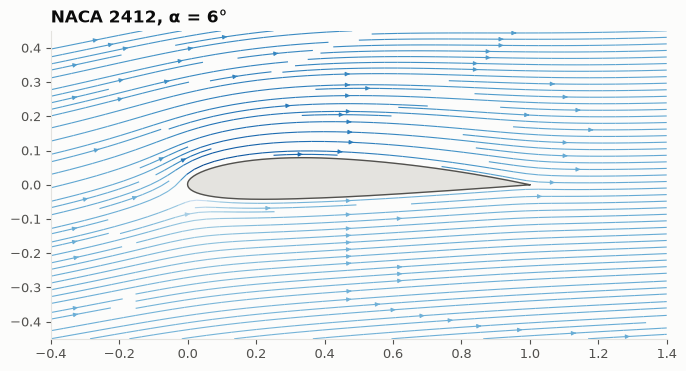

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
P.streamlines(ax, sol, extent=(-0.4, 1.4, -0.45, 0.45))
ax.set_title("NACA 2412, α = 6°");

## Exact benchmark: Joukowski airfoil

The conformal map gives the exact potential flow, so the panel-method error can be measured directly.

In [4]:
jk = Joukowski(0.1, 0.1)
for n in (50, 100, 200, 400, 800):
    s = solve_panels(jk.coordinates(n), 5 * DEG)
    print(f"N = {n:4d}: cl = {s.cl:.4f}  (exact {jk.cl(5 * DEG):.4f}, error {100 * (s.cl / jk.cl(5 * DEG) - 1):+.2f}%)")

N =   50: cl = 1.1438  (exact 1.2181, error -6.10%)
N =  100: cl = 1.1677  (exact 1.2181, error -4.14%)
N =  200: cl = 1.1861  (exact 1.2181, error -2.62%)
N =  400: cl = 1.1988  (exact 1.2181, error -1.58%)
N =  800: cl = 1.2069  (exact 1.2181, error -0.92%)


First-order convergence: the cusped trailing edge is the hardest case for constant-strength panels.